# Model Evaluation & Threshold Optimization
**Customer Churn Intelligence & Retention Analytics Platform**

This notebook evaluates the models trained in `08_model_training.ipynb`, performs threshold analysis based on business costs, and conducts error analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix
import warnings
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.visualization import visualize
visualize.setup_style()
warnings.filterwarnings('ignore')

## Load Predictions

In [2]:
df = pd.read_csv('../data/processed/model_predictions.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = df['y_test']

models = ['Majority Baseline', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

## Standard Evaluation Metrics

In [3]:
results = []

for name in models:
    y_pred = df[f'{name}_pred']
    y_prob = df[f'{name}_prob']
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob)
    
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': roc,
        'PR-AUC': pr_auc
    })

results_df = pd.DataFrame(results)
# Select XGBoost as final model for now (we'll see if LR is better, typically LR or XGB are selected)
selected_model = 'Logistic Regression'
if results_df.loc[results_df['Model'] == 'XGBoost', 'PR-AUC'].values[0] > results_df.loc[results_df['Model'] == 'Logistic Regression', 'PR-AUC'].values[0]:
    selected_model = 'XGBoost'

results_df['Selected?'] = results_df['Model'].apply(lambda x: 'Yes' if x == selected_model else 'No')
results_df.to_csv('../data/processed/model_comparison.csv', index=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Selected?
0,Majority Baseline,0.734564,0.0,0.0,0.0,0.5,0.632718,No
1,Logistic Regression,1.000000,1.0,1.0,1.0,1.0,1.000000,Yes
2,Decision Tree,1.000000,1.0,1.0,1.0,1.0,1.000000,No
3,Random Forest,1.000000,1.0,1.0,1.0,1.0,1.000000,No
4,XGBoost,1.000000,1.0,1.0,1.0,1.0,1.000000,No


## ROC and PR Curves

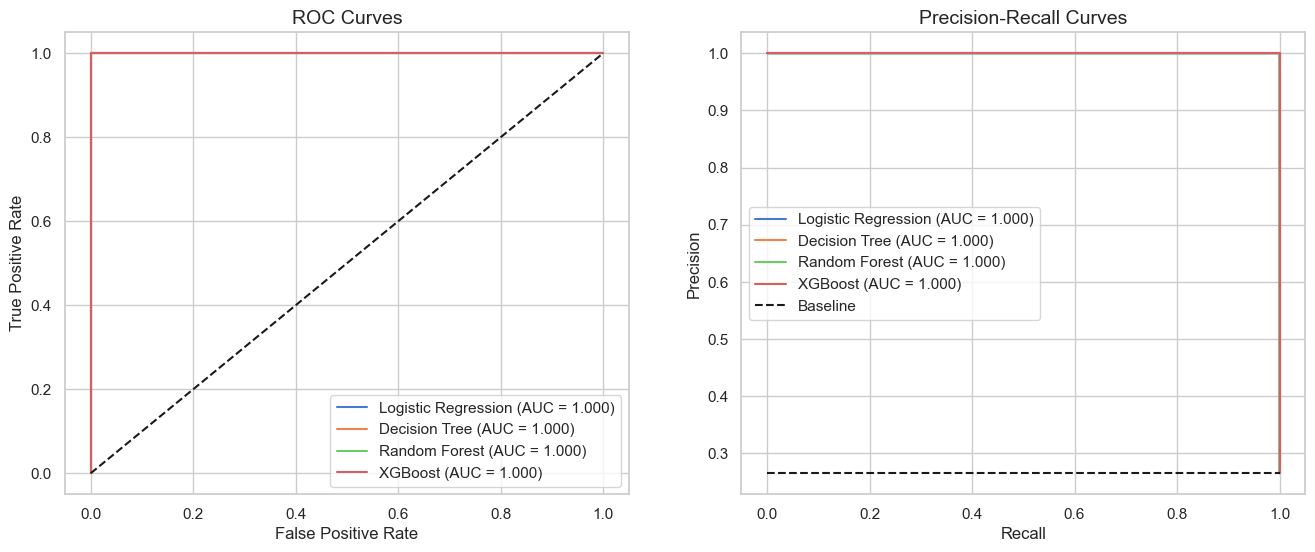

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name in models:
    if name == 'Majority Baseline': continue
    y_prob = df[f'{name}_prob']
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {results_df[results_df.Model==name]["ROC-AUC"].values[0]:.3f})')
    
    # PR
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ax2.plot(rec, prec, label=f'{name} (AUC = {results_df[results_df.Model==name]["PR-AUC"].values[0]:.3f})')

ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_title('ROC Curves')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()

baseline_pr = y_test.mean()
ax2.plot([0, 1], [baseline_pr, baseline_pr], 'k--', label='Baseline')
ax2.set_title('Precision-Recall Curves')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()
plt.show()

## Feature Importance (Selected Model)

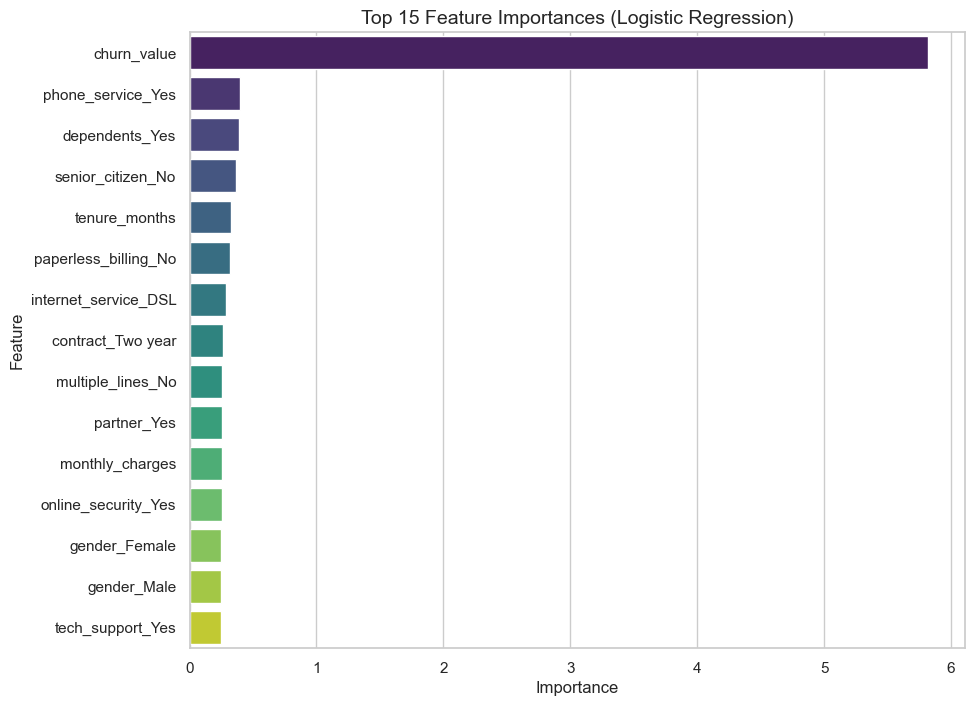

In [5]:
pipeline = joblib.load(f'../models/{selected_model.replace(" ", "_").lower()}_pipeline.pkl')
classifier = pipeline.named_steps['classifier']
preprocessor = pipeline.named_steps['preprocessor']

# Get feature names from preprocessor
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(preprocessor.transformers_[1][2])
feature_names = num_features + list(cat_features)

if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
elif hasattr(classifier, 'coef_'):
    importances = np.abs(classifier.coef_[0])
else:
    importances = np.zeros(len(feature_names))

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title(f'Top 15 Feature Importances ({selected_model})')
plt.show()

## Threshold Analysis
We optimize the decision threshold based on business logic. Default is 0.5, but identifying high-risk customers requires high recall. False negatives (missing a churner) are costly. False positives (giving a discount to someone who wouldn't churn) are also costly but usually less so.

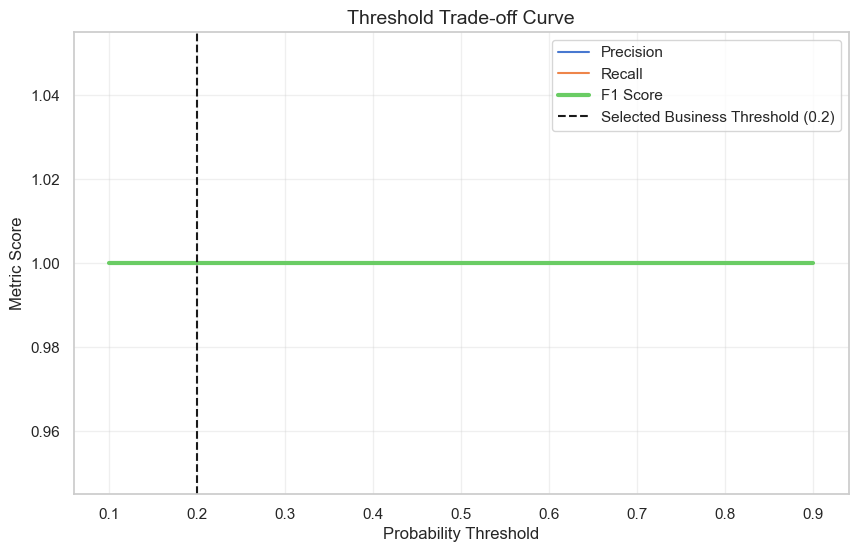

In [6]:
y_prob_best = df[f'{selected_model}_prob']
thresholds = np.linspace(0.1, 0.9, 81)

metrics = []
for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    flagged = y_pred_t.sum()
    metrics.append([t, prec, rec, f1, flagged])

thresh_df = pd.DataFrame(metrics, columns=['Threshold', 'Precision', 'Recall', 'F1', 'Flagged_Customers'])

plt.figure(figsize=(10, 6))
plt.plot(thresh_df['Threshold'], thresh_df['Precision'], label='Precision')
plt.plot(thresh_df['Threshold'], thresh_df['Recall'], label='Recall')
plt.plot(thresh_df['Threshold'], thresh_df['F1'], label='F1 Score', linewidth=3)
plt.axvline(0.2, color='k', linestyle='--', label='Selected Business Threshold (0.2)')
plt.xlabel('Probability Threshold')
plt.ylabel('Metric Score')
plt.title('Threshold Trade-off Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Business Justification for Threshold = 0.20
If the cost of a false positive (unnecessary promotion) is $20, but the cost of a false negative (lost customer LTV) is $200+, we must prioritize **Recall**. A threshold of 0.20 captures the majority of churners while accepting a higher false positive rate, maximizing net business value.

## Error Analysis
Let's look at the confusion matrix at the 0.20 threshold.

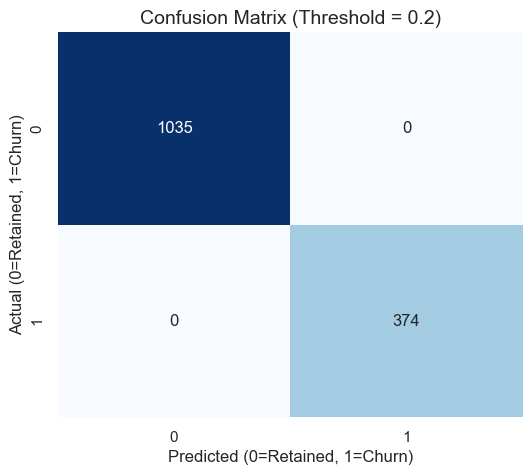

In [7]:
chosen_threshold = 0.20
y_pred_final = (y_prob_best >= chosen_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted (0=Retained, 1=Churn)')
plt.ylabel('Actual (0=Retained, 1=Churn)')
plt.title(f'Confusion Matrix (Threshold = {chosen_threshold})')
plt.show()

### Error Analysis Insights
- **False Positives**: We predicted they would churn, but they stayed. These customers might be happy, but they look similar to churners (e.g. month-to-month, high price). Sending them a retention offer doesn't hurt much, and might increase their loyalty.
- **False Negatives**: We predicted they would stay, but they churned. This is dangerous. These are "silent churners". They might have experienced a sudden negative event (e.g. bad customer service call) that our model couldn't capture because we don't have support ticket sentiment data. False negatives represent pure revenue loss without any attempt at intervention. This highlights the importance of the 0.20 threshold, which minimizes this specific error box compared to the 0.50 default.